# 🛍️ Customer Shopping Behavior & Consumer Trends Analytics
### An end-to-end Python + SQL + Power BI portfolio project

---

## 📌 Business Context
A leading retail company wants to understand **customer shopping behavior across demographics, product categories and channels** in order to improve **sales, customer satisfaction and long-term loyalty**. Leadership wants to know which factors — **discounts, reviews, seasons, payment preferences** — drive purchase decisions and repeat purchases.

## ❓ Overarching Business Question
> **"How can the company leverage consumer shopping data to identify trends, improve customer engagement, and optimize marketing and product strategies?"**

## 🗂️ Dataset (3,900 rows × 16 columns)
| Group | Columns |
|---|---|
| Demographics & Location | Customer ID, Age, Gender, Location |
| Product & Purchase | Item Purchased, Category, Purchase Amount (USD), Size, Color, Season |
| Experience & Engagement | Review Rating, Subscription Status, Discount Applied, Previous Purchases, Payment Method, Frequency of Purchases |

## 🧭 Notebook Roadmap
| # | Section | Tooling |
|---|---|---|
| 1 | Data Preparation & Feature Engineering | Python / Pandas |
| 2 | Data Analysis with SQL (in-memory SQLite) | SQL via `sqlite3` |
| 3 | Visualization & Insights | Matplotlib / Seaborn |
| 4 | Power BI Dashboard Blueprint | DAX + design guide |
| 5 | Executive Summary & Interview Talking Points | Storytelling |

## ▶️ How to run
1. Put your CSV next to this notebook and set `DATA_PATH` in the config cell (default: `shopping_behavior.csv`).
2. If the file is **not found**, the notebook generates a **clearly-labelled synthetic placeholder dataset** with the same schema so every cell still runs. **Replace it with your real data before drawing any conclusions.**
3. Run **Kernel → Restart & Run All**.

---
# 1️⃣ Data Preparation & Modeling (Python / Pandas)

**Goals**
1. Load the data and inspect shape, types, nulls and duplicates.
2. Clean it (standardize names, fix types, handle missing values).
3. Engineer features analysts actually use: age brackets, spend tiers, loyalty segments, numeric purchase frequency, binary flags.

> 💡 **Mentor tip:** Always *inspect before you clean* and *validate after you clean*. Interviewers love hearing "I added assertions to prove my cleaning worked."

## 1.1 Setup: imports, global config and helpers

In [1]:
# ----------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------
import warnings
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # keep notebook output clean for a portfolio

# ----------------------------------------------------------------------
# Global configuration  (change these in ONE place)
# ----------------------------------------------------------------------
DATA_PATH = Path("shopping_behavior.csv")      # <- path to YOUR csv
CLEAN_PATH = Path("cleaned_shopping_data.csv") # <- cleaned file for Power BI
DB_PATH = Path("shopping.db")                  # <- optional on-disk copy of the SQLite DB
FIG_DIR = Path("figures")                      # <- charts get saved here
FIG_DIR.mkdir(exist_ok=True)

REPEAT_THRESHOLD = 10   # business rule: >= 10 previous purchases = "repeat/loyal" customer
SEASON_ORDER = ["Spring", "Summer", "Fall", "Winter"]
AMT = "purchase_amount_usd"                    # short alias for the long column name

# ----------------------------------------------------------------------
# Display & plotting style
# ----------------------------------------------------------------------
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook", palette="viridis")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

def save_fig(name: str) -> None:
    """Tidy layout, save a high-res PNG into /figures, then display it."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Setup complete ✅")

Setup complete ✅


## 1.2 Load the dataset
If your CSV is missing, the helper below builds a **synthetic placeholder** with the same 16 columns so the notebook stays runnable (great for testing / GitHub demos).

In [2]:
def make_synthetic_data(n: int = 3900, seed: int = 42) -> pd.DataFrame:
    """Create a PLACEHOLDER dataset with the same schema as the real one.
    Only used if the real CSV can't be found. Not real customer data!"""
    rng = np.random.default_rng(seed)
    catalog = {
        "Clothing":    ["Blouse", "Dress", "Jeans", "Pants", "Shirt", "Skirt", "Sweater", "T-shirt", "Socks", "Shorts"],
        "Footwear":    ["Sandals", "Sneakers", "Shoes", "Boots", "Slippers"],
        "Accessories": ["Jewelry", "Sunglasses", "Belt", "Scarf", "Hat", "Handbag", "Backpack", "Gloves"],
        "Outerwear":   ["Jacket", "Coat", "Hoodie"],
    }
    cat_p = [0.44, 0.16, 0.32, 0.08]
    categories = rng.choice(list(catalog), size=n, p=cat_p)
    items = [rng.choice(catalog[c]) for c in categories]
    states = ["Montana", "California", "Idaho", "Illinois", "Alabama", "Minnesota", "New York", "Nevada",
              "Ohio", "Texas", "Florida", "Oregon", "Maine", "Georgia", "Utah", "Vermont"]
    freq = ["Weekly", "Fortnightly", "Bi-Weekly", "Monthly", "Quarterly", "Every 3 Months", "Annually"]
    df = pd.DataFrame({
        "Customer ID": np.arange(1, n + 1),
        "Age": rng.integers(18, 71, n),
        "Gender": rng.choice(["Male", "Female"], n, p=[0.68, 0.32]),
        "Item Purchased": items,
        "Category": categories,
        "Purchase Amount (USD)": rng.integers(20, 101, n),
        "Location": rng.choice(states, n),
        "Size": rng.choice(["S", "M", "L", "XL"], n, p=[0.17, 0.45, 0.27, 0.11]),
        "Color": rng.choice(["Black", "White", "Blue", "Red", "Gray", "Olive", "Pink", "Teal"], n),
        "Season": rng.choice(SEASON_ORDER, n),
        "Review Rating": np.round(rng.uniform(2.5, 5.0, n), 1),
        "Subscription Status": rng.choice(["Yes", "No"], n, p=[0.27, 0.73]),
        "Payment Method": rng.choice(["Credit Card", "PayPal", "Cash", "Venmo", "Debit Card", "Bank Transfer"], n),
        "Discount Applied": rng.choice(["Yes", "No"], n, p=[0.43, 0.57]),
        "Previous Purchases": rng.integers(1, 51, n),
        "Frequency of Purchases": rng.choice(freq, n),
    })
    # Inject ~1% missing ratings so the cleaning step has something to do
    df.loc[rng.choice(n, size=int(0.01 * n), replace=False), "Review Rating"] = np.nan
    return df


if DATA_PATH.exists():
    df_raw = pd.read_csv(DATA_PATH)
    print(f"✅ Loaded real data from {DATA_PATH}")
else:
    df_raw = make_synthetic_data()
    print(f"⚠️ '{DATA_PATH}' not found -> using SYNTHETIC placeholder data. Replace before drawing conclusions!")

print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

⚠️ 'shopping_behavior.csv' not found -> using SYNTHETIC placeholder data. Replace before drawing conclusions!
Shape: 3,900 rows x 16 columns


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Discount Applied,Previous Purchases,Frequency of Purchases
0,1,54,Male,Scarf,Accessories,100,Ohio,M,Olive,Fall,3.40,No,Bank Transfer,Yes,19,Annually
1,2,70,Female,Dress,Clothing,51,Maine,M,Teal,Spring,4.70,No,Debit Card,No,27,Every 3 Months
2,3,62,Male,Handbag,Accessories,71,Nevada,L,Black,Summer,2.50,No,Bank Transfer,Yes,13,Annually
3,4,63,Male,Backpack,Accessories,83,Alabama,S,Black,Spring,4.80,No,Credit Card,No,13,Quarterly
4,5,23,Male,T-shirt,Clothing,83,Montana,M,Olive,Winter,3.40,Yes,PayPal,Yes,31,Fortnightly


## 1.3 Initial inspection: types, nulls, duplicates, distributions
We **never modify `df_raw`** — it stays as the untouched source of truth.

In [3]:
# --- Structure and data types ---
print("=== INFO ===")
df_raw.info()

# --- Missing values (count + percentage) ---
print("\n=== MISSING VALUES ===")
null_report = (
    df_raw.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda d: d["null_count"] / len(df_raw) * 100)
    .query("null_count > 0")
)
print(null_report if len(null_report) else "No missing values 🎉")

# --- Duplicates: full-row duplicates AND duplicate customer IDs ---
id_col = "Customer ID"
print("\n=== DUPLICATES ===")
print(f"Fully duplicated rows : {df_raw.duplicated().sum()}")
print(f"Duplicate Customer IDs: {df_raw[id_col].duplicated().sum()}")

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3861 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Payment Method          3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Previous Purchases      3900 non-null 

In [4]:
# --- Numeric summary: look for impossible values (negative amounts, age 0, rating > 5) ---
display(df_raw.describe().T)

# --- Categorical values: spot typos / inconsistent labels (e.g. 'Bi-Weekly' vs 'Fortnightly') ---
cat_cols = df_raw.select_dtypes(include=["object", "string"]).columns.drop(["Item Purchased", "Location"], errors="ignore")
for col in cat_cols:
    print(f"\n{col}  ({df_raw[col].nunique()} unique)")
    print(df_raw[col].value_counts(dropna=False).to_dict())

,count,mean,std,min,25%,50%,75%,max
Customer ID,"3,900.00","1,950.50","1,125.98",1.00,975.75,"1,950.50","2,925.25","3,900.00"
Age,"3,900.00",43.73,15.28,18.00,31.00,44.00,57.00,70.00
Purchase Amount (USD),"3,900.00",59.69,23.46,20.00,39.00,60.00,80.00,100.00
Review Rating,"3,861.00",3.74,0.72,2.50,3.10,3.70,4.40,5.00
Previous Purchases,"3,900.00",25.47,14.43,1.00,13.00,26.00,38.00,50.00



Gender  (2 unique)
{'Male': 2636, 'Female': 1264}

Category  (4 unique)
{'Clothing': 1721, 'Accessories': 1221, 'Footwear': 627, 'Outerwear': 331}

Size  (4 unique)
{'M': 1696, 'L': 1075, 'S': 667, 'XL': 462}

Color  (8 unique)
{'Teal': 524, 'Pink': 518, 'Gray': 489, 'Olive': 483, 'Black': 480, 'Blue': 470, 'White': 469, 'Red': 467}

Season  (4 unique)
{'Spring': 989, 'Summer': 989, 'Winter': 972, 'Fall': 950}

Subscription Status  (2 unique)
{'No': 2866, 'Yes': 1034}

Payment Method  (6 unique)
{'Credit Card': 673, 'Debit Card': 667, 'PayPal': 666, 'Cash': 652, 'Venmo': 633, 'Bank Transfer': 609}

Discount Applied  (2 unique)
{'No': 2215, 'Yes': 1685}

Frequency of Purchases  (7 unique)
{'Quarterly': 588, 'Annually': 582, 'Bi-Weekly': 561, 'Weekly': 553, 'Monthly': 549, 'Every 3 Months': 548, 'Fortnightly': 519}


### 🔎 What to note from inspection (write your own findings here)
- Which columns have nulls and how many? *(typically `Review Rating`)*
- Are there duplicate rows or IDs? If **Customer ID is unique**, each row = one customer's purchase record. This matters for how we define "repeat purchase" later — we use **`Previous Purchases`** since there is no order-date column.
- Are there category labels that mean the same thing (e.g. *Bi-Weekly* / *Fortnightly*, *Quarterly* / *Every 3 Months*)? We'll standardize them numerically.

## 1.4 Data cleaning
Steps: standardize column names → trim text → drop duplicates → impute missing ratings → validate.

**Why impute the rating with the *category median*?** Ratings are bounded (1–5) and slightly skewed; the median is robust to outliers, and category-level medians keep category differences intact (better than one global value). We also keep a flag column so imputation is transparent.

In [5]:
df = df_raw.copy()

# 1) Standardize column names -> snake_case  ("Purchase Amount (USD)" -> "purchase_amount_usd")
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

# 2) Trim whitespace in text columns (hidden spaces break GROUP BY and joins)
text_cols = df.select_dtypes(include=["object", "string"]).columns
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

# 3) Remove duplicates (full-row duplicates, then duplicate customer IDs - keep first)
before = len(df)
df = df.drop_duplicates().drop_duplicates(subset="customer_id", keep="first").reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows")

# 4) Handle missing review ratings: flag first, then fill with the CATEGORY median
df["rating_was_imputed"] = df["review_rating"].isna().astype(int)
df["review_rating"] = df.groupby("category")["review_rating"].transform(lambda s: s.fillna(s.median()))
df["review_rating"] = df["review_rating"].fillna(df["review_rating"].median())  # safety net
print(f"Imputed {df['rating_was_imputed'].sum()} missing ratings")

# 5) Enforce proper data types
df["age"] = df["age"].astype(int)
df["previous_purchases"] = df["previous_purchases"].astype(int)
df[AMT] = df[AMT].astype(float)
df["season"] = pd.Categorical(df["season"], categories=SEASON_ORDER, ordered=True)

df.head()

Removed 0 duplicate rows
Imputed 39 missing ratings


,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,payment_method,discount_applied,previous_purchases,frequency_of_purchases,rating_was_imputed
0,1,54,Male,Scarf,Accessories,100.00,Ohio,M,Olive,Fall,3.40,No,Bank Transfer,Yes,19,Annually,0
1,2,70,Female,Dress,Clothing,51.00,Maine,M,Teal,Spring,4.70,No,Debit Card,No,27,Every 3 Months,0
2,3,62,Male,Handbag,Accessories,71.00,Nevada,L,Black,Summer,2.50,No,Bank Transfer,Yes,13,Annually,0
3,4,63,Male,Backpack,Accessories,83.00,Alabama,S,Black,Spring,4.80,No,Credit Card,No,13,Quarterly,0
4,5,23,Male,T-shirt,Clothing,83.00,Montana,M,Olive,Winter,3.40,Yes,PayPal,Yes,31,Fortnightly,0


## 1.5 Feature engineering
New columns turn raw data into **business segments**:

| Feature | Logic | Business use |
|---|---|---|
| `age_group` | Fixed bins (18-24, 25-34 …) | Demographic targeting |
| `spend_tier` | Quartiles of purchase amount | Identify premium shoppers |
| `loyalty_segment` | Bins of previous purchases | Retention / loyalty programs |
| `is_repeat_customer` | `previous_purchases >= REPEAT_THRESHOLD` | Repeat purchase rate KPI |
| `frequency_days` | Text frequency -> approx. days between purchases | Numeric analysis of purchase cadence |
| `discount_flag`, `subscribed` | Yes/No -> 1/0 | Easy averages = rates |
| `rating_band` | Low / Medium / High | Satisfaction segments |

In [6]:
# ----- Age brackets -----
age_bins   = [17, 24, 34, 44, 54, 64, 120]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

# ----- Spend tiers (quartile-based so each tier holds ~25% of purchases) -----
df["spend_tier"] = pd.qcut(df[AMT], q=4, labels=["Low", "Mid-Low", "Mid-High", "High"], duplicates="drop")

# ----- Loyalty segment from purchase history -----
df["loyalty_segment"] = pd.cut(
    df["previous_purchases"],
    bins=[-1, 5, 15, 30, np.inf],
    labels=["New (0-5)", "Occasional (6-15)", "Regular (16-30)", "Loyal (31+)"],
)

# ----- Repeat-customer flag (explicit, tweakable business rule) -----
df["is_repeat_customer"] = (df["previous_purchases"] >= REPEAT_THRESHOLD).astype(int)

# ----- Convert text frequency to approximate days between purchases -----
freq_to_days = {
    "weekly": 7, "fortnightly": 14, "bi-weekly": 14,
    "monthly": 30, "quarterly": 90, "every 3 months": 90, "annually": 365,
}
df["frequency_days"] = df["frequency_of_purchases"].str.lower().map(freq_to_days)
assert df["frequency_days"].notna().all(), "Unmapped frequency label found - update freq_to_days!"

# ----- Binary flags -----
df["discount_flag"] = (df["discount_applied"].str.lower() == "yes").astype(int)
df["subscribed"]    = (df["subscription_status"].str.lower() == "yes").astype(int)

# ----- Rating band -----
df["rating_band"] = pd.cut(df["review_rating"], bins=[0, 3.5, 4.5, 5.01], right=False,
                           labels=["Low (<3.5)", "Medium (3.5-4.4)", "High (4.5+)"])

df[["age", "age_group", AMT, "spend_tier", "previous_purchases", "loyalty_segment",
    "is_repeat_customer", "frequency_of_purchases", "frequency_days"]].head(8)

,age,age_group,purchase_amount_usd,spend_tier,previous_purchases,loyalty_segment,is_repeat_customer,frequency_of_purchases,frequency_days
0,54,45-54,100.00,High,19,Regular (16-30),1,Annually,365
1,70,65+,51.00,Mid-Low,27,Regular (16-30),1,Every 3 Months,90
2,62,55-64,71.00,Mid-High,13,Occasional (6-15),1,Annually,365
3,63,55-64,83.00,High,13,Occasional (6-15),1,Quarterly,90
4,23,18-24,83.00,High,31,Loyal (31+),1,Fortnightly,14
5,19,18-24,36.00,Low,29,Regular (16-30),1,Bi-Weekly,14
6,68,65+,97.00,High,40,Loyal (31+),1,Annually,365
7,31,25-34,60.00,Mid-Low,45,Loyal (31+),1,Fortnightly,14


## 1.6 Validation checks & export for Power BI

In [7]:
# Assertions = automatic proof the data is trustworthy
assert df.isna().sum().sum() == 0,           "Nulls remain!"
assert df["customer_id"].is_unique,           "Customer IDs not unique!"
assert df["age"].between(18, 100).all(),      "Age out of range!"
assert (df[AMT] > 0).all(),                   "Non-positive purchase amounts!"
assert df["review_rating"].between(1, 5).all(), "Rating out of 1-5 range!"
print("✅ All validation checks passed")

print(f"Final shape: {df.shape}")
for seg_col in ["age_group", "spend_tier", "loyalty_segment", "rating_band"]:
    print(f"\n{seg_col} distribution:")
    print((df[seg_col].value_counts(normalize=True, sort=False) * 100).round(1).astype(str).add("%").to_dict())

# Export cleaned dataset (used in Section 4 for Power BI)
df.to_csv(CLEAN_PATH, index=False)
print(f"Saved cleaned data -> {CLEAN_PATH}")

✅ All validation checks passed
Final shape: (3900, 25)

age_group distribution:
{'18-24': '13.9%', '25-34': '18.2%', '35-44': '19.4%', '45-54': '19.0%', '55-64': '18.4%', '65+': '11.1%'}

spend_tier distribution:
{'Low': '25.8%', 'Mid-Low': '25.4%', 'Mid-High': '24.6%', 'High': '24.2%'}

loyalty_segment distribution:
{'New (0-5)': '10.1%', 'Occasional (6-15)': '19.7%', 'Regular (16-30)': '29.8%', 'Loyal (31+)': '40.4%'}

rating_band distribution:
{'Low (<3.5)': '38.7%', 'Medium (3.5-4.4)': '39.7%', 'High (4.5+)': '21.6%'}
Saved cleaned data -> cleaned_shopping_data.csv


---
# 2️⃣ Data Analysis & SQL Simulation (SQLite)

Analysts spend much of their day in SQL, so we move the cleaned data into a **relational database** and answer business questions with queries.

**Note on `shopping.db`:** SQLite can run fully **in memory** (`":memory:"`, fast and disposable). We use an in-memory connection for analysis and then *optionally* back it up to a `shopping.db` file so you can open it in DB Browser for SQLite or attach it to Power BI.

## 2.1 Ingest the cleaned data

In [8]:
# Convert categoricals to plain strings so SQLite stores clean TEXT columns
df_sql = df.copy()
for col in df_sql.select_dtypes(include="category").columns:
    df_sql[col] = df_sql[col].astype(str)
for col in df_sql.select_dtypes(include="string").columns:
    df_sql[col] = df_sql[col].astype(str)

# In-memory database
conn = sqlite3.connect(":memory:")
df_sql.to_sql("shopping", conn, index=False, if_exists="replace")

# Indexes speed up GROUP BY / WHERE / JOIN on frequently-used columns
for idx_col in ["category", "season", "age_group", "discount_applied", "customer_id"]:
    conn.execute(f"CREATE INDEX IF NOT EXISTS idx_shopping_{idx_col} ON shopping({idx_col});")
conn.commit()

def run_query(sql: str) -> pd.DataFrame:
    """Execute SQL and return a DataFrame (keeps notebook cells tidy)."""
    return pd.read_sql_query(sql, conn)

# Optional: persist a copy to disk as shopping.db
with sqlite3.connect(DB_PATH) as disk_conn:
    conn.backup(disk_conn)
print(f"Table 'shopping' loaded: {run_query('SELECT COUNT(*) AS n FROM shopping').iloc[0, 0]:,} rows | disk copy -> {DB_PATH}")

run_query("PRAGMA table_info(shopping);")[["name", "type"]].T

Table 'shopping' loaded: 3,900 rows | disk copy -> shopping.db


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
name,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,payment_method,discount_applied,previous_purchases,frequency_of_purchases,rating_was_imputed,age_group,spend_tier,loyalty_segment,is_repeat_customer,frequency_days,discount_flag,subscribed,rating_band
type,INTEGER,INTEGER,TEXT,TEXT,TEXT,REAL,TEXT,TEXT,TEXT,TEXT,REAL,TEXT,TEXT,TEXT,INTEGER,TEXT,INTEGER,TEXT,TEXT,TEXT,INTEGER,INTEGER,INTEGER,INTEGER,TEXT


## 2.2 Query 1 — Executive KPI snapshot
*Business question: What is the overall health of the business?*

In [9]:
q_kpi = """
SELECT
    COUNT(*)                                   AS total_transactions,
    COUNT(DISTINCT customer_id)                AS unique_customers,
    ROUND(SUM(purchase_amount_usd), 0)         AS total_revenue,
    ROUND(AVG(purchase_amount_usd), 2)         AS avg_order_value,
    ROUND(AVG(review_rating), 2)               AS avg_rating,
    ROUND(100.0 * AVG(discount_flag), 1)       AS pct_with_discount,
    ROUND(100.0 * AVG(subscribed), 1)          AS pct_subscribed,
    ROUND(100.0 * AVG(is_repeat_customer), 1)  AS repeat_purchase_rate_pct
FROM shopping;
"""
run_query(q_kpi)

,total_transactions,unique_customers,total_revenue,avg_order_value,avg_rating,pct_with_discount,pct_subscribed,repeat_purchase_rate_pct
0,3900,3900,"232,780.00",59.69,3.74,43.20,26.50,81.60


## 2.3 Query 2 — Category performance with revenue share
*Business question: Which categories earn the most?*  
Uses a **window function** (`SUM() OVER ()`) to compute each category's share of total revenue in a single pass.

In [10]:
q_category = """
SELECT
    category,
    COUNT(*)                                              AS transactions,
    ROUND(SUM(purchase_amount_usd), 0)                    AS revenue,
    ROUND(AVG(purchase_amount_usd), 2)                    AS avg_order_value,
    ROUND(AVG(review_rating), 2)                          AS avg_rating,
    ROUND(100.0 * SUM(purchase_amount_usd)
          / SUM(SUM(purchase_amount_usd)) OVER (), 1)     AS revenue_share_pct
FROM shopping
GROUP BY category
ORDER BY revenue DESC;
"""
run_query(q_category)

,category,transactions,revenue,avg_order_value,avg_rating,revenue_share_pct
0,Clothing,1721,"102,273.00",59.43,3.74,43.90
1,Accessories,1221,"72,268.00",59.19,3.74,31.00
2,Footwear,627,"38,698.00",61.72,3.78,16.60
3,Outerwear,331,"19,541.00",59.04,3.74,8.40


## 2.4 Query 3 — Top 3 products inside each category
*Business question: Which items should we feature or stock deeper?*  
Uses a **CTE + `ROW_NUMBER()`** window function — the classic "top-N per group" interview pattern.

In [11]:
q_top_items = """
WITH item_rev AS (
    SELECT category,
           item_purchased,
           COUNT(*)                           AS units_sold,
           ROUND(SUM(purchase_amount_usd), 0) AS revenue,
           ROUND(AVG(review_rating), 2)       AS avg_rating
    FROM shopping
    GROUP BY category, item_purchased
),
ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY category ORDER BY revenue DESC) AS rnk
    FROM item_rev
)
SELECT category, rnk AS rank, item_purchased, units_sold, revenue, avg_rating
FROM ranked
WHERE rnk <= 3
ORDER BY category, rnk;
"""
run_query(q_top_items)

,category,rank,item_purchased,units_sold,revenue,avg_rating
0,Accessories,1,Scarf,168,"10,179.00",3.71
1,Accessories,2,Belt,165,"9,729.00",3.71
2,Accessories,3,Gloves,153,"9,403.00",3.77
3,Clothing,1,Sweater,192,"11,271.00",3.84
4,Clothing,2,Skirt,193,"11,267.00",3.70
5,Clothing,3,Socks,172,"10,729.00",3.70
6,Footwear,1,Sandals,132,"8,411.00",3.78
7,Footwear,2,Boots,136,"8,333.00",3.74
8,Footwear,3,Sneakers,119,"7,684.00",3.84
9,Outerwear,1,Jacket,116,"6,873.00",3.68


## 2.5 Query 4 — Customer segments: age group × gender
*Business question: Which demographic segments drive the most spend?*  
`HAVING` removes tiny, statistically unreliable segments.

In [12]:
q_segments = """
SELECT
    age_group,
    gender,
    COUNT(*)                              AS customers,
    ROUND(SUM(purchase_amount_usd), 0)    AS revenue,
    ROUND(AVG(purchase_amount_usd), 2)    AS avg_spend,
    ROUND(AVG(previous_purchases), 1)     AS avg_prev_purchases
FROM shopping
GROUP BY age_group, gender
HAVING COUNT(*) >= 30
ORDER BY revenue DESC;
"""
run_query(q_segments)

,age_group,gender,customers,revenue,avg_spend,avg_prev_purchases
0,55-64,Male,508,"30,293.00",59.63,25.80
1,35-44,Male,512,"29,985.00",58.56,25.80
2,45-54,Male,471,"28,505.00",60.52,26.70
3,25-34,Male,475,"28,388.00",59.76,26.10
4,18-24,Male,374,"22,112.00",59.12,25.70
5,65+,Male,296,"17,651.00",59.63,22.80
6,45-54,Female,271,"16,095.00",59.39,24.10
7,35-44,Female,245,"14,923.00",60.91,26.00
8,25-34,Female,233,"13,744.00",58.99,24.10
9,55-64,Female,211,"12,307.00",58.33,25.90


## 2.6 Query 5 — Purchasing driver: do discounts change spending?
*Business question: Do discounts lift basket size, or just cut margin?*  
Compare discounted vs non-discounted purchases overall and by category.

In [13]:
q_discount = """
SELECT
    category,
    discount_applied,
    COUNT(*)                              AS transactions,
    ROUND(AVG(purchase_amount_usd), 2)    AS avg_spend,
    ROUND(AVG(review_rating), 2)          AS avg_rating,
    ROUND(AVG(previous_purchases), 1)     AS avg_prev_purchases
FROM shopping
GROUP BY category, discount_applied
ORDER BY category, discount_applied;
"""
display(run_query(q_discount))

# Overall lift in a single row (conditional aggregation = very common interview technique)
q_discount_lift = """
SELECT
    ROUND(AVG(CASE WHEN discount_flag = 1 THEN purchase_amount_usd END), 2) AS avg_spend_discount,
    ROUND(AVG(CASE WHEN discount_flag = 0 THEN purchase_amount_usd END), 2) AS avg_spend_no_discount,
    ROUND(AVG(CASE WHEN discount_flag = 1 THEN purchase_amount_usd END)
        - AVG(CASE WHEN discount_flag = 0 THEN purchase_amount_usd END), 2) AS difference_usd
FROM shopping;
"""
run_query(q_discount_lift)

,category,discount_applied,transactions,avg_spend,avg_rating,avg_prev_purchases
0,Accessories,No,703,59.22,3.72,25.00
1,Accessories,Yes,518,59.14,3.76,26.50
2,Clothing,No,966,59.43,3.75,25.40
3,Clothing,Yes,755,59.42,3.72,26.10
4,Footwear,No,356,63.15,3.76,24.70
5,Footwear,Yes,271,59.83,3.80,24.00
6,Outerwear,No,190,57.58,3.73,24.90
7,Outerwear,Yes,141,60.99,3.76,26.80


,avg_spend_discount,avg_spend_no_discount,difference_usd
0,59.53,59.80,-0.27


## 2.7 Query 6 — Seasonality: revenue by season and category (pivot in SQL)
*Business question: When should we push which category?*  
SQLite has no `PIVOT`, so we use **conditional aggregation** (`SUM(CASE WHEN ...)`).

In [14]:
q_season = """
SELECT
    season,
    ROUND(SUM(CASE WHEN category = 'Clothing'    THEN purchase_amount_usd END), 0) AS clothing,
    ROUND(SUM(CASE WHEN category = 'Footwear'    THEN purchase_amount_usd END), 0) AS footwear,
    ROUND(SUM(CASE WHEN category = 'Accessories' THEN purchase_amount_usd END), 0) AS accessories,
    ROUND(SUM(CASE WHEN category = 'Outerwear'   THEN purchase_amount_usd END), 0) AS outerwear,
    ROUND(SUM(purchase_amount_usd), 0)                                             AS total
FROM shopping
GROUP BY season
ORDER BY CASE season WHEN 'Spring' THEN 1 WHEN 'Summer' THEN 2 WHEN 'Fall' THEN 3 ELSE 4 END;
"""
run_query(q_season)

,season,clothing,footwear,accessories,outerwear,total
0,Spring,"26,453.00","9,905.00","18,084.00","5,185.00","59,627.00"
1,Summer,"25,338.00","11,650.00","18,068.00","5,026.00","60,082.00"
2,Fall,"24,751.00","7,826.00","18,828.00","4,855.00","56,260.00"
3,Winter,"25,731.00","9,317.00","17,288.00","4,475.00","56,811.00"


## 2.8 Query 7 — Loyalty drivers: subscription, payment method, purchase frequency
*Business question: Which behaviors go with higher spend and more repeat buying?*

In [15]:
q_subscription = """
SELECT
    CASE WHEN subscribed = 1 THEN 'Subscriber' ELSE 'Non-subscriber' END AS customer_type,
    COUNT(*)                                  AS customers,
    ROUND(AVG(purchase_amount_usd), 2)        AS avg_spend,
    ROUND(AVG(previous_purchases), 1)         AS avg_prev_purchases,
    ROUND(100.0 * AVG(is_repeat_customer), 1) AS repeat_rate_pct,
    ROUND(AVG(review_rating), 2)              AS avg_rating
FROM shopping
GROUP BY subscribed;
"""
display(run_query(q_subscription))

q_payment = """
SELECT
    payment_method,
    COUNT(*)                                       AS transactions,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS share_pct,
    ROUND(AVG(purchase_amount_usd), 2)             AS avg_spend
FROM shopping
GROUP BY payment_method
ORDER BY transactions DESC;
"""
display(run_query(q_payment))

q_frequency = """
SELECT
    frequency_of_purchases,
    frequency_days,
    COUNT(*)                                  AS customers,
    ROUND(AVG(purchase_amount_usd), 2)        AS avg_spend,
    ROUND(AVG(previous_purchases), 1)         AS avg_prev_purchases
FROM shopping
GROUP BY frequency_of_purchases, frequency_days
ORDER BY frequency_days;
"""
run_query(q_frequency)

,customer_type,customers,avg_spend,avg_prev_purchases,repeat_rate_pct,avg_rating
0,Non-subscriber,2866,59.53,25.10,81.20,3.74
1,Subscriber,1034,60.12,26.50,82.90,3.75


,payment_method,transactions,share_pct,avg_spend
0,Credit Card,673,17.30,58.64
1,Debit Card,667,17.10,60.74
2,PayPal,666,17.10,59.13
3,Cash,652,16.70,59.36
4,Venmo,633,16.20,60.34
5,Bank Transfer,609,15.60,59.96


,frequency_of_purchases,frequency_days,customers,avg_spend,avg_prev_purchases
0,Weekly,7,553,59.59,24.80
1,Bi-Weekly,14,561,60.24,25.10
2,Fortnightly,14,519,57.92,26.20
3,Monthly,30,549,59.97,24.70
4,Every 3 Months,90,548,60.57,25.70
5,Quarterly,90,588,58.16,25.30
6,Annually,365,582,61.26,26.50


## 2.9 Query 8 — JOIN: build a customer-segment table and join it back
*Business question: Who are our VIPs (high spend AND high loyalty)?*

This demonstrates a **join** by creating a second table (`customer_segments`) with `NTILE(4)` quartiles, then joining it to the fact table.

In [16]:
# Build a dimension-style table with NTILE window functions
conn.executescript("""
DROP TABLE IF EXISTS customer_segments;
CREATE TABLE customer_segments AS
SELECT
    customer_id,
    NTILE(4) OVER (ORDER BY purchase_amount_usd)  AS spend_quartile,    -- 4 = highest spenders
    NTILE(4) OVER (ORDER BY previous_purchases)   AS loyalty_quartile   -- 4 = most loyal
FROM shopping;
CREATE INDEX idx_seg_customer ON customer_segments(customer_id);
""")

q_vip = """
SELECT
    CASE
        WHEN seg.spend_quartile = 4 AND seg.loyalty_quartile = 4 THEN '1. VIP (high spend + high loyalty)'
        WHEN seg.spend_quartile = 4 AND seg.loyalty_quartile < 4 THEN '2. Big spenders - low loyalty'
        WHEN seg.spend_quartile < 4 AND seg.loyalty_quartile = 4 THEN '3. Loyal - lower spend'
        ELSE '4. Everyone else'
    END                                         AS value_segment,
    COUNT(*)                                    AS customers,
    ROUND(SUM(s.purchase_amount_usd), 0)        AS revenue,
    ROUND(AVG(s.purchase_amount_usd), 2)        AS avg_spend,
    ROUND(100.0 * AVG(s.subscribed), 1)         AS pct_subscribed,
    ROUND(100.0 * AVG(s.discount_flag), 1)      AS pct_discounted
FROM shopping AS s
INNER JOIN customer_segments AS seg
        ON s.customer_id = seg.customer_id
GROUP BY value_segment
ORDER BY value_segment;
"""
run_query(q_vip)

,value_segment,customers,revenue,avg_spend,pct_subscribed,pct_discounted
0,1. VIP (high spend + high loyalty),250,"22,753.00",91.01,33.20,44.80
1,2. Big spenders - low loyalty,725,"65,365.00",90.16,27.00,43.90
2,3. Loyal - lower spend,725,"36,106.00",49.80,27.00,43.40
3,4. Everyone else,2200,"108,556.00",49.34,25.40,42.70


## 2.10 Query 9 — Geography: top locations with a minimum-volume filter

In [17]:
q_location = """
SELECT
    location,
    COUNT(*)                              AS transactions,
    ROUND(SUM(purchase_amount_usd), 0)    AS revenue,
    ROUND(AVG(purchase_amount_usd), 2)    AS avg_spend,
    ROUND(AVG(review_rating), 2)          AS avg_rating
FROM shopping
WHERE location IS NOT NULL
GROUP BY location
HAVING COUNT(*) >= 20
ORDER BY revenue DESC
LIMIT 10;
"""
run_query(q_location)

,location,transactions,revenue,avg_spend,avg_rating
0,Maine,261,"16,230.00",62.18,3.73
1,Texas,265,"16,082.00",60.69,3.68
2,Minnesota,266,"15,402.00",57.90,3.80
3,Georgia,257,"15,261.00",59.38,3.71
4,Utah,258,"15,237.00",59.06,3.77
5,Vermont,250,"15,029.00",60.12,3.72
6,Illinois,249,"14,881.00",59.76,3.79
7,Florida,250,"14,768.00",59.07,3.66
8,Alabama,233,"14,245.00",61.14,3.79
9,New York,234,"14,236.00",60.84,3.77


## 2.11 Bonus — proving the query is "optimized"
`EXPLAIN QUERY PLAN` shows whether SQLite uses an **index** (`SEARCH ... USING INDEX`) or scans the entire table (`SCAN`). Mentioning this in interviews signals you think about performance, not just correctness.

In [18]:
plan = run_query("EXPLAIN QUERY PLAN SELECT category, SUM(purchase_amount_usd) FROM shopping WHERE season = 'Winter' GROUP BY category;")
plan[["detail"]]

,detail
0,SEARCH shopping USING INDEX idx_shopping_seaso...
1,USE TEMP B-TREE FOR GROUP BY


---
# 3️⃣ Visualization & Insights (Matplotlib / Seaborn)

Each chart answers a **specific business question**. Good portfolio charts have: a clear title, labelled axes, a sensible sort order and a one-line "so what?".

> 💡 **Mentor tip:** After every chart, write the *insight* in markdown using your real numbers. That is the difference between a chart gallery and an analysis.

## 3.1 Sales by Category & Season
*Which categories peak in which season?*

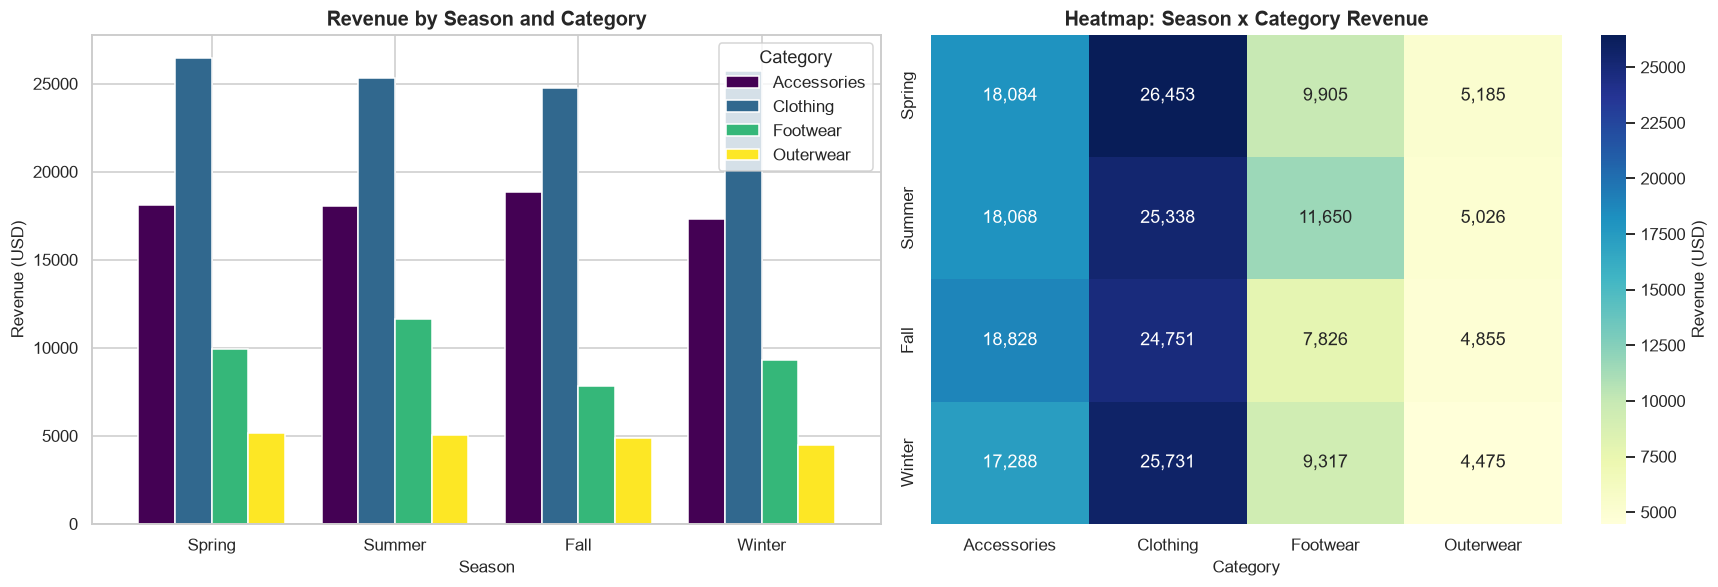

In [19]:
season_cat = (df.pivot_table(index="season", columns="category", values=AMT, aggfunc="sum", observed=True)
                .reindex(SEASON_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Left: grouped bars for comparing categories within each season
season_cat.plot(kind="bar", ax=axes[0], width=0.8, edgecolor="white", colormap="viridis")
axes[0].set_title("Revenue by Season and Category")
axes[0].set_xlabel("Season"); axes[0].set_ylabel("Revenue (USD)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Category")

# Right: heatmap makes the strongest season/category combos pop
sns.heatmap(season_cat, annot=True, fmt=",.0f", cmap="YlGnBu", ax=axes[1], cbar_kws={"label": "Revenue (USD)"})
axes[1].set_title("Heatmap: Season x Category Revenue")
axes[1].set_xlabel("Category"); axes[1].set_ylabel("")

save_fig("01_sales_by_category_season")

**📝 Insight to write:** *Which season is the strongest overall? Which category–season combination is the single largest cell? Does Outerwear actually peak in Winter?*

## 3.2 Impact of Discounts on Purchase Amount
*Do discounts increase how much customers spend?*

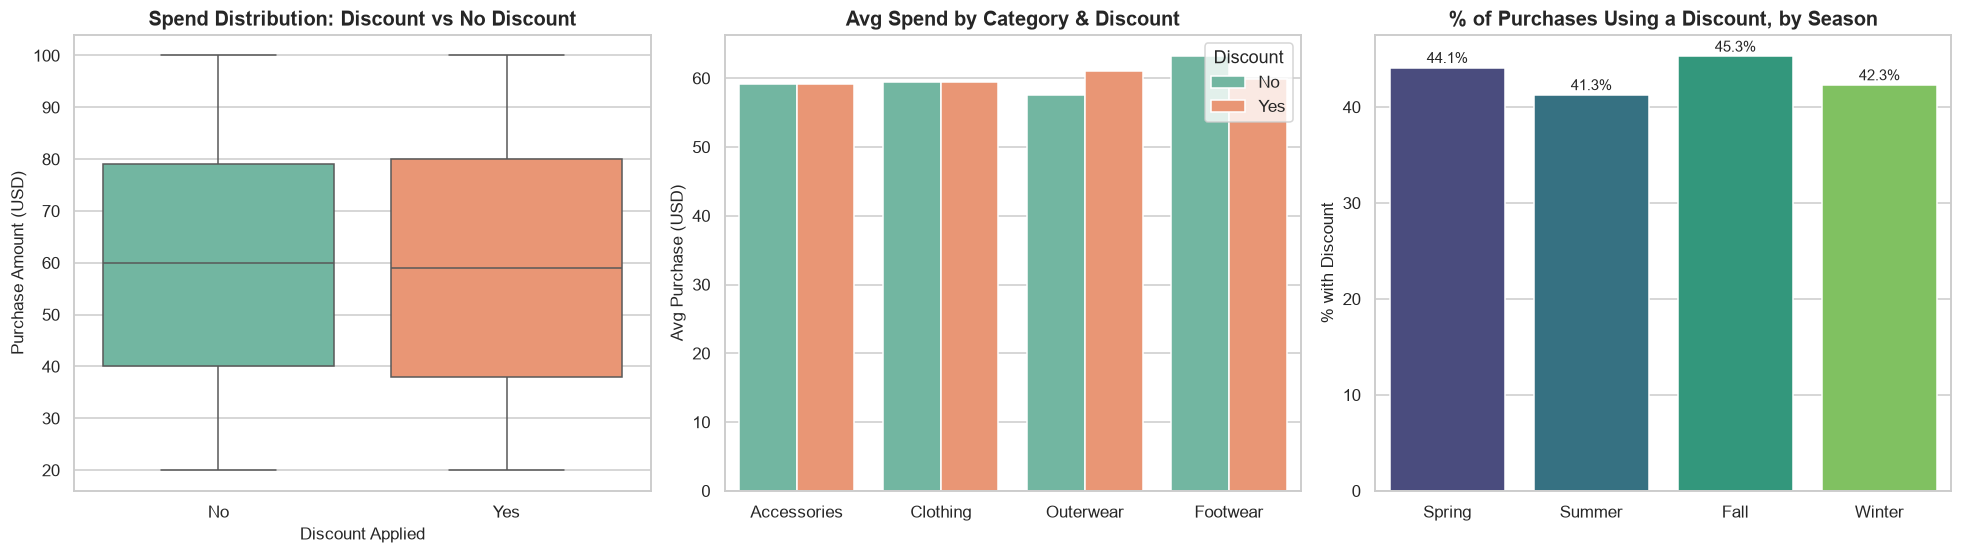

Avg spend WITH discount: $59.53 | WITHOUT: $59.80 | diff = $-0.27 (approx. 95% CI: -1.77 to 1.22)
-> If the confidence interval includes 0, the discount effect on basket size is NOT statistically distinguishable from zero.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

# (a) Distribution of spend with vs without discount
sns.boxplot(data=df, x="discount_applied", y=AMT, order=["No", "Yes"], ax=axes[0], palette="Set2")
axes[0].set_title("Spend Distribution: Discount vs No Discount")
axes[0].set_xlabel("Discount Applied"); axes[0].set_ylabel("Purchase Amount (USD)")

# (b) Average spend per category, split by discount
sns.barplot(data=df, x="category", y=AMT, hue="discount_applied", hue_order=["No", "Yes"],
            errorbar=None, ax=axes[1], palette="Set2")
axes[1].set_title("Avg Spend by Category & Discount")
axes[1].set_xlabel(""); axes[1].set_ylabel("Avg Purchase (USD)")
axes[1].legend(title="Discount")

# (c) Share of purchases using a discount, by season
disc_rate = df.groupby("season", observed=True)["discount_flag"].mean().reindex(SEASON_ORDER) * 100
sns.barplot(x=disc_rate.index, y=disc_rate.values, ax=axes[2], palette="viridis")
axes[2].set_title("% of Purchases Using a Discount, by Season")
axes[2].set_xlabel(""); axes[2].set_ylabel("% with Discount")
for i, v in enumerate(disc_rate.values):
    axes[2].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

save_fig("02_discount_impact")

# Quick statistical sanity check: is the difference real or just noise?
a = df.loc[df.discount_flag == 1, AMT]; b = df.loc[df.discount_flag == 0, AMT]
diff = a.mean() - b.mean()
se = np.sqrt(a.var() / len(a) + b.var() / len(b))
print(f"Avg spend WITH discount: ${a.mean():.2f} | WITHOUT: ${b.mean():.2f} | diff = ${diff:.2f} (approx. 95% CI: {diff - 1.96*se:.2f} to {diff + 1.96*se:.2f})")
print("-> If the confidence interval includes 0, the discount effect on basket size is NOT statistically distinguishable from zero.")

**📝 Insight to write:** *If discounts don't raise basket size, they may only reduce margin — recommend targeted (not blanket) promotions.*

## 3.3 Customer Demographics vs Spending
*Which age groups and genders spend the most?*

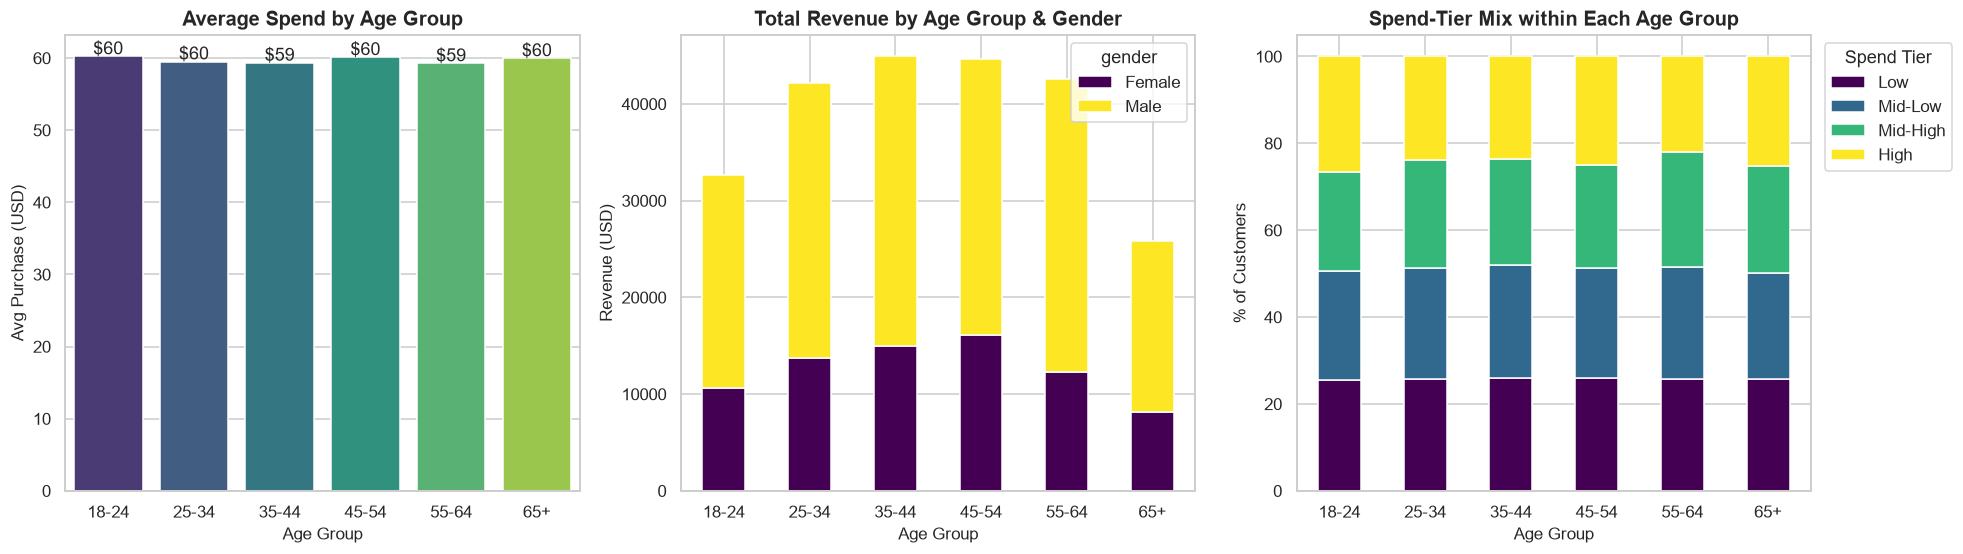

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

# (a) Average spend by age group
age_avg = df.groupby("age_group", observed=True)[AMT].mean()
sns.barplot(x=age_avg.index.astype(str), y=age_avg.values, ax=axes[0], palette="viridis")
axes[0].set_title("Average Spend by Age Group")
axes[0].set_xlabel("Age Group"); axes[0].set_ylabel("Avg Purchase (USD)")
for i, v in enumerate(age_avg.values):
    axes[0].text(i, v + 0.3, f"${v:.0f}", ha="center")

# (b) Total revenue by age group and gender (where the money really comes from)
rev_ag = df.pivot_table(index="age_group", columns="gender", values=AMT, aggfunc="sum", observed=True)
rev_ag.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis", edgecolor="white")
axes[1].set_title("Total Revenue by Age Group & Gender")
axes[1].set_xlabel("Age Group"); axes[1].set_ylabel("Revenue (USD)")
axes[1].tick_params(axis="x", rotation=0)

# (c) Spend-tier mix by age group (100% stacked)
tier_mix = pd.crosstab(df["age_group"], df["spend_tier"], normalize="index") * 100
tier_mix.plot(kind="bar", stacked=True, ax=axes[2], colormap="viridis", edgecolor="white")
axes[2].set_title("Spend-Tier Mix within Each Age Group")
axes[2].set_xlabel("Age Group"); axes[2].set_ylabel("% of Customers")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Spend Tier", bbox_to_anchor=(1.01, 1), loc="upper left")

save_fig("03_demographics_vs_spend")

**📝 Insight to write:** *Revenue is driven by both **average spend** and **segment size**. A group with a lower average spend can still be your biggest revenue source if it has the most customers.*

## 3.4 Review Ratings Breakdown
*How satisfied are customers, and where are the weak spots?*

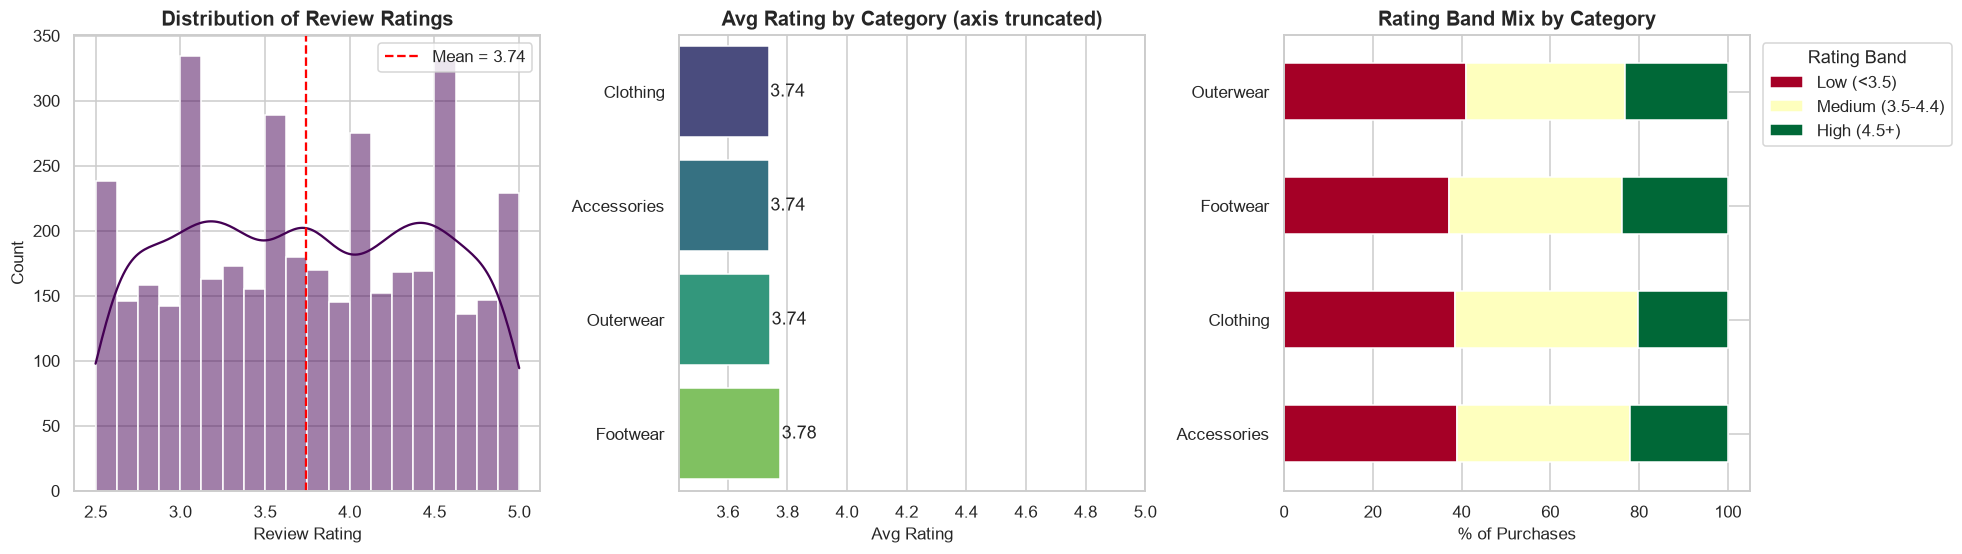

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

# (a) Overall rating distribution
sns.histplot(df["review_rating"], bins=20, kde=True, color="#440154", ax=axes[0])
axes[0].axvline(df["review_rating"].mean(), color="red", ls="--", label=f"Mean = {df['review_rating'].mean():.2f}")
axes[0].set_title("Distribution of Review Ratings")
axes[0].set_xlabel("Review Rating"); axes[0].legend()

# (b) Avg rating by category - zoomed axis to show differences (note the truncated axis!)
cat_rating = df.groupby("category")["review_rating"].mean().sort_values()
sns.barplot(x=cat_rating.values, y=cat_rating.index, ax=axes[1], palette="viridis")
axes[1].set_xlim(max(0, cat_rating.min() - 0.3), 5)
axes[1].set_title("Avg Rating by Category (axis truncated)")
axes[1].set_xlabel("Avg Rating"); axes[1].set_ylabel("")
for i, v in enumerate(cat_rating.values):
    axes[1].text(v + 0.005, i, f"{v:.2f}", va="center")

# (c) Rating band mix by category (100% stacked)
band = pd.crosstab(df["category"], df["rating_band"], normalize="index") * 100
band.plot(kind="barh", stacked=True, ax=axes[2], colormap="RdYlGn", edgecolor="white")
axes[2].set_title("Rating Band Mix by Category")
axes[2].set_xlabel("% of Purchases"); axes[2].set_ylabel("")
axes[2].legend(title="Rating Band", bbox_to_anchor=(1.01, 1), loc="upper left")

save_fig("04_review_ratings")

**📝 Insight to write:** *Does a higher rating associate with higher spend or more repeat purchases (see correlation heatmap in 3.8)? Which category has the largest share of low ratings?*

## 3.5 Loyalty Drivers: Subscription & Repeat Purchases
*Do subscribers buy more often and spend more?*

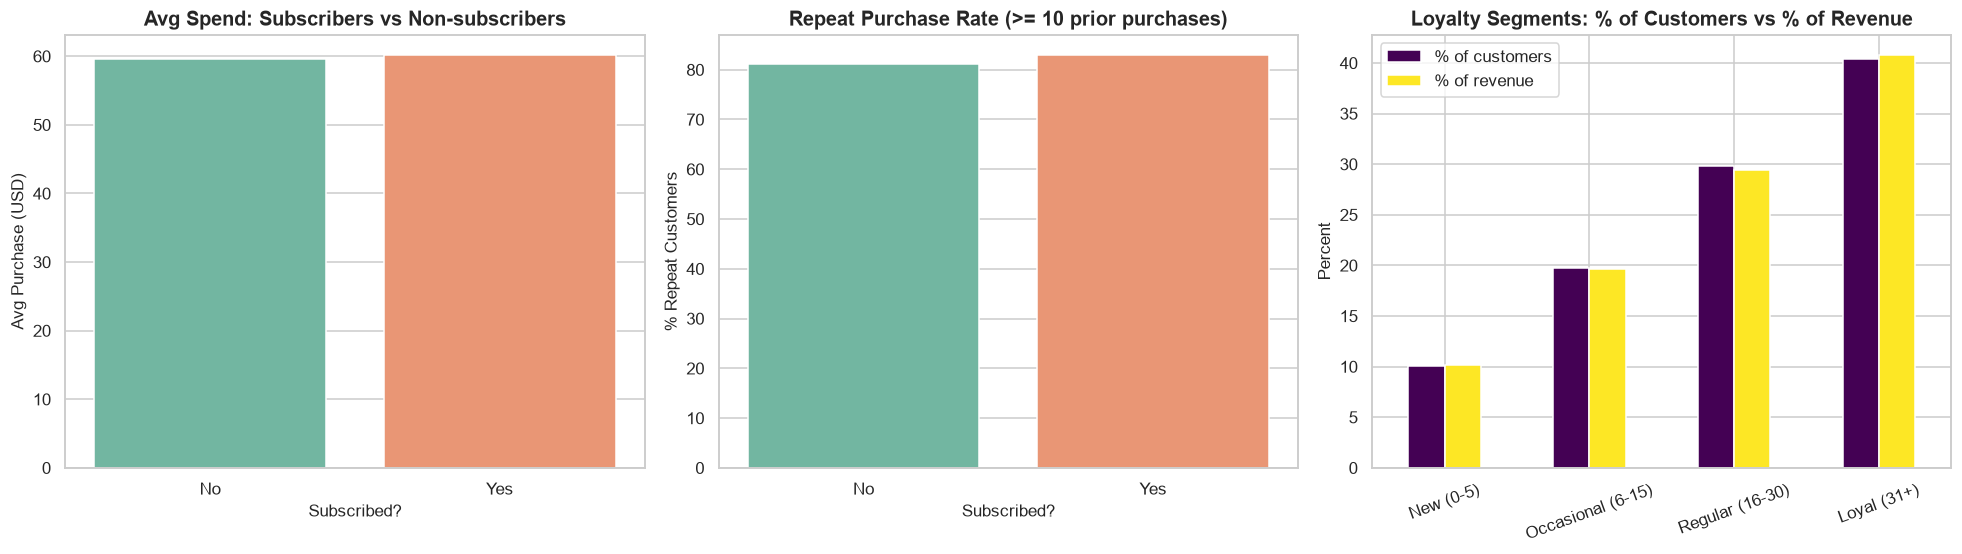

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

sub_summary = df.groupby("subscription_status").agg(
    avg_spend=(AMT, "mean"),
    avg_prev=("previous_purchases", "mean"),
    repeat_rate=("is_repeat_customer", "mean"),
)

# (a) Avg spend, subscribers vs non
sns.barplot(x=sub_summary.index, y=sub_summary["avg_spend"], ax=axes[0], palette="Set2", order=["No", "Yes"])
axes[0].set_title("Avg Spend: Subscribers vs Non-subscribers")
axes[0].set_xlabel("Subscribed?"); axes[0].set_ylabel("Avg Purchase (USD)")

# (b) Repeat-purchase rate
sns.barplot(x=sub_summary.index, y=sub_summary["repeat_rate"] * 100, ax=axes[1], palette="Set2", order=["No", "Yes"])
axes[1].set_title(f"Repeat Purchase Rate (>= {REPEAT_THRESHOLD} prior purchases)")
axes[1].set_xlabel("Subscribed?"); axes[1].set_ylabel("% Repeat Customers")

# (c) Loyalty-segment size and its share of revenue
loy = df.groupby("loyalty_segment", observed=True).agg(customers=("customer_id", "count"), revenue=(AMT, "sum"))
loy_pct = loy / loy.sum() * 100
loy_pct.plot(kind="bar", ax=axes[2], colormap="viridis", edgecolor="white")
axes[2].set_title("Loyalty Segments: % of Customers vs % of Revenue")
axes[2].set_xlabel(""); axes[2].set_ylabel("Percent")
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend(["% of customers", "% of revenue"])

save_fig("05_loyalty_subscription")

## 3.6 Payment Preferences & Purchase Frequency

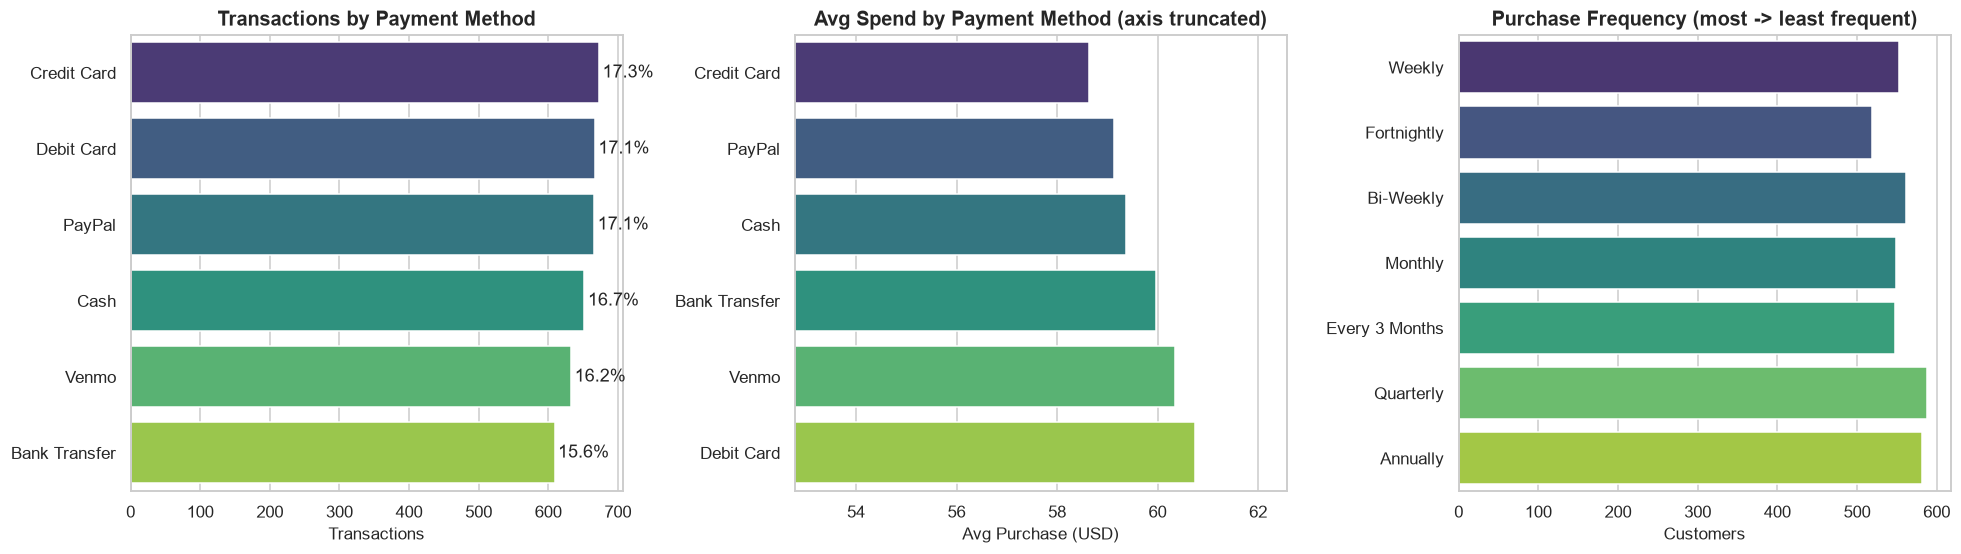

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

# (a) Payment method share
pay = df["payment_method"].value_counts()
sns.barplot(x=pay.values, y=pay.index, ax=axes[0], palette="viridis")
axes[0].set_title("Transactions by Payment Method")
axes[0].set_xlabel("Transactions"); axes[0].set_ylabel("")
for i, v in enumerate(pay.values):
    axes[0].text(v + 5, i, f"{v / pay.sum():.1%}", va="center")

# (b) Avg spend by payment method
pay_spend = df.groupby("payment_method")[AMT].mean().sort_values()
sns.barplot(x=pay_spend.values, y=pay_spend.index, ax=axes[1], palette="viridis")
axes[1].set_xlim(pay_spend.min() * 0.9, pay_spend.max() * 1.03)
axes[1].set_title("Avg Spend by Payment Method (axis truncated)")
axes[1].set_xlabel("Avg Purchase (USD)"); axes[1].set_ylabel("")

# (c) Purchase frequency, ordered from most to least frequent
freq_order = (df[["frequency_of_purchases", "frequency_days"]].drop_duplicates()
                .sort_values("frequency_days")["frequency_of_purchases"].tolist())
sns.countplot(data=df, y="frequency_of_purchases", order=freq_order, ax=axes[2], palette="viridis")
axes[2].set_title("Purchase Frequency (most -> least frequent)")
axes[2].set_xlabel("Customers"); axes[2].set_ylabel("")

save_fig("06_payment_frequency")

## 3.7 Geography: Top 10 Locations by Revenue

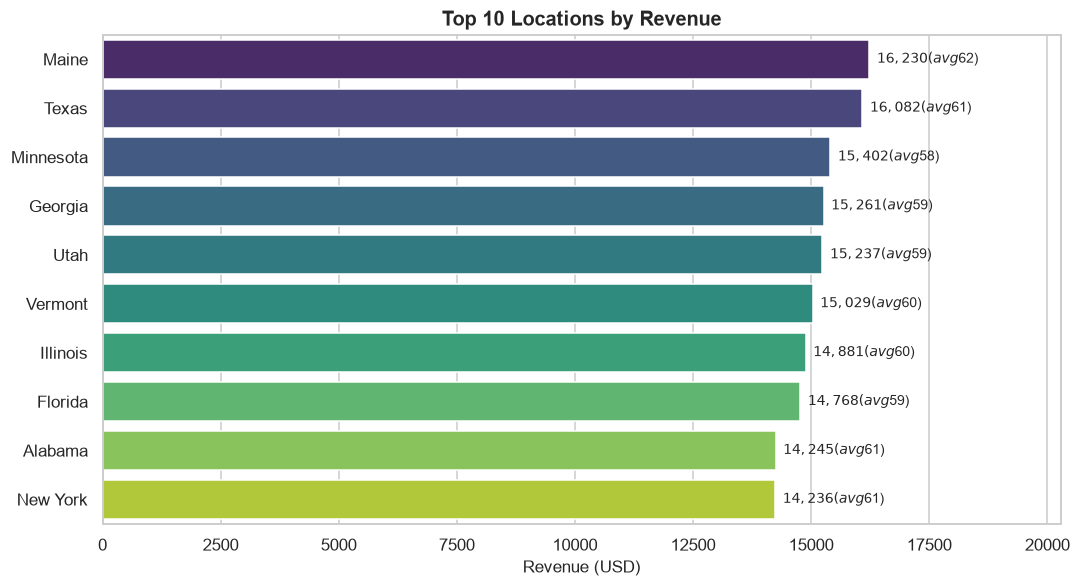

In [25]:
top_loc = df.groupby("location")[AMT].agg(["sum", "mean", "count"]).query("count >= 20").nlargest(10, "sum")

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(x=top_loc["sum"], y=top_loc.index, palette="viridis", ax=ax)
ax.set_title("Top 10 Locations by Revenue")
ax.set_xlabel("Revenue (USD)"); ax.set_ylabel("")
for i, (rev, avg) in enumerate(zip(top_loc["sum"], top_loc["mean"])):
    ax.text(rev + top_loc["sum"].max() * 0.01, i, f"${rev:,.0f}  (avg ${avg:.0f})", va="center", fontsize=9)
ax.set_xlim(0, top_loc["sum"].max() * 1.25)
save_fig("07_top_locations")

## 3.8 What moves together? Correlation heatmap
*Pearson correlation shows **linear association**, not causation.*

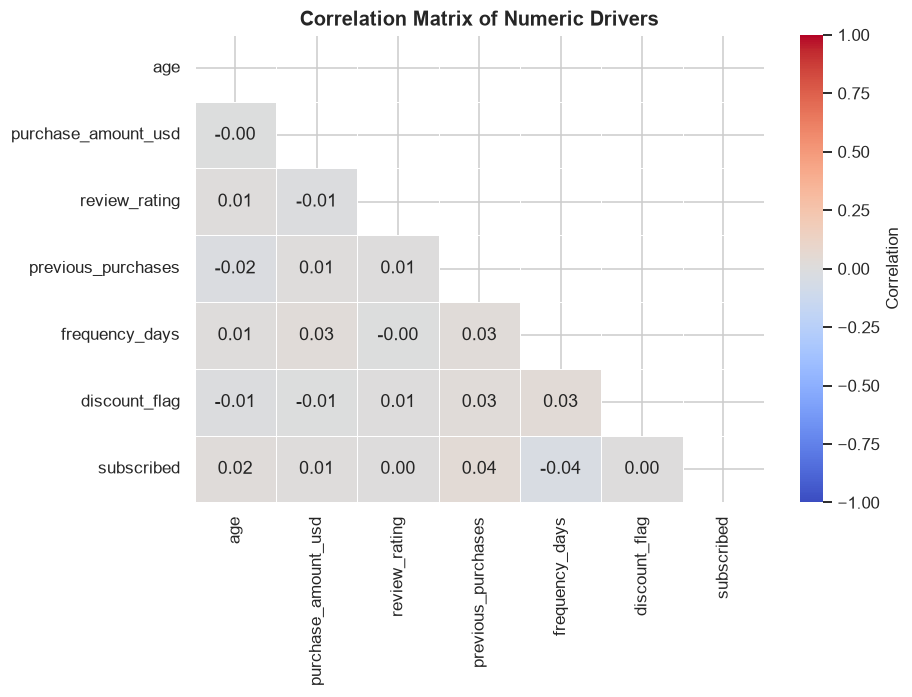

In [26]:
corr_cols = ["age", AMT, "review_rating", "previous_purchases", "frequency_days", "discount_flag", "subscribed"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8.5, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool))      # hide the redundant upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"label": "Correlation"}, ax=ax)
ax.set_title("Correlation Matrix of Numeric Drivers")
save_fig("08_correlation_heatmap")

**📝 Insight to write:** *Are any correlations above ~0.3 in absolute value? If everything is near 0, say so — "no single variable strongly predicts spend" is a valid and honest finding, and it supports **segment-based** rather than one-size-fits-all strategies.*

In [27]:
# ---- Headline metrics ----
total_rev   = df[AMT].sum()
aov         = df[AMT].mean()
avg_rating  = df["review_rating"].mean()
repeat_rate = df["is_repeat_customer"].mean() * 100

# ---- Category / season ----
cat_rev        = df.groupby("category")[AMT].sum().sort_values(ascending=False)
season_rev     = df.groupby("season", observed=True)[AMT].sum()
top_cat        = cat_rev.index[0]
top_season     = season_rev.idxmax()
cs             = df.groupby(["season", "category"], observed=True)[AMT].sum()
top_cs         = cs.idxmax()

# ---- Discounts ----
disc_avg    = df.loc[df.discount_flag == 1, AMT].mean()
nodisc_avg  = df.loc[df.discount_flag == 0, AMT].mean()
disc_share  = df["discount_flag"].mean() * 100

# ---- Demographics ----
age_rev        = df.groupby("age_group", observed=True)[AMT].sum()
age_avg        = df.groupby("age_group", observed=True)[AMT].mean()
gender_rev_pct = df.groupby("gender")[AMT].sum() / total_rev * 100

# ---- Loyalty ----
sub = df.groupby("subscription_status").agg(spend=(AMT, "mean"), prev=("previous_purchases", "mean"), rep=("is_repeat_customer", "mean"))

# ---- Payments ----
top_pay = df["payment_method"].value_counts(normalize=True)

print("=" * 70)
print("KEY FINDINGS (auto-generated from the data)")
print("=" * 70)
print(f"1. SCALE      : ${total_rev:,.0f} revenue | AOV ${aov:.2f} | avg rating {avg_rating:.2f}/5 | repeat rate {repeat_rate:.1f}% (threshold = {REPEAT_THRESHOLD}+ prior purchases)")
print(f"2. CATEGORY   : '{top_cat}' leads with {cat_rev.iloc[0] / total_rev:.1%} of revenue; lowest is '{cat_rev.index[-1]}' ({cat_rev.iloc[-1] / total_rev:.1%}).")
print(f"3. SEASONALITY: '{top_season}' is the top season (${season_rev.max():,.0f}); biggest season-category cell = {top_cs[0]} / {top_cs[1]} (${cs.max():,.0f}).")
print(f"4. DISCOUNTS  : {disc_share:.1f}% of purchases use a discount. Avg spend ${disc_avg:.2f} (discount) vs ${nodisc_avg:.2f} (no discount) -> difference ${disc_avg - nodisc_avg:+.2f}.")
print(f"5. DEMOGRAPHICS: biggest revenue age group = {age_rev.idxmax()} ({age_rev.max() / total_rev:.1%} of revenue); highest avg spend = {age_avg.idxmax()} (${age_avg.max():.2f}).")
print(f"               Gender revenue split: " + ", ".join(f"{g} {p:.1f}%" for g, p in gender_rev_pct.items()))
if {"Yes", "No"} <= set(sub.index):
    print(f"6. LOYALTY    : Subscribers avg spend ${sub.loc['Yes','spend']:.2f} vs ${sub.loc['No','spend']:.2f}; repeat rate {sub.loc['Yes','rep']:.1%} vs {sub.loc['No','rep']:.1%}.")
print(f"7. PAYMENTS   : most-used = {top_pay.index[0]} ({top_pay.iloc[0]:.1%}), then {top_pay.index[1]} ({top_pay.iloc[1]:.1%}).")

KEY FINDINGS (auto-generated from the data)
1. SCALE      : $232,780 revenue | AOV $59.69 | avg rating 3.74/5 | repeat rate 81.6% (threshold = 10+ prior purchases)
2. CATEGORY   : 'Clothing' leads with 43.9% of revenue; lowest is 'Outerwear' (8.4%).
3. SEASONALITY: 'Summer' is the top season ($60,082); biggest season-category cell = Spring / Clothing ($26,453).
4. DISCOUNTS  : 43.2% of purchases use a discount. Avg spend $59.53 (discount) vs $59.80 (no discount) -> difference $-0.27.
5. DEMOGRAPHICS: biggest revenue age group = 35-44 (19.3% of revenue); highest avg spend = 18-24 ($60.22).
               Gender revenue split: Female 32.6%, Male 67.4%
6. LOYALTY    : Subscribers avg spend $60.12 vs $59.53; repeat rate 82.9% vs 81.2%.
7. PAYMENTS   : most-used = Credit Card (17.3%), then Debit Card (17.1%).


In [28]:
# Final sanity check: SQL and Pandas should agree. If they do, you can trust both.
sql_total = run_query("SELECT SUM(purchase_amount_usd) AS total FROM shopping").iloc[0, 0]
pd_total  = df[AMT].sum()
assert np.isclose(sql_total, pd_total), "SQL and Pandas totals disagree!"
print(f"✅ SQL total (${sql_total:,.0f}) matches Pandas total (${pd_total:,.0f})")
conn.close()

✅ SQL total ($232,780) matches Pandas total ($232,780)
